In [ ]:
import pandas as pd
from bromo import evaluations as bromo_eval
from bromo_eval.tka import plot_protein_ranking, eval_q1_dataframes
from bromo_eval.utils import avg_fwdrev_score,prepare_dfs


In [ ]:
bromo_preds_path_astral = '../../Datasets/inference/yeast-astral/full_predictions.tsv'
bromo_preds_astral = prepare_dfs(bromo_preds_path_astral)
bromo_uniquepair_astral = avg_fwdrev_score(bromo_preds_astral)


prego_yeast = pd.read_csv('../../Datasets/external_baselines/yeast/prego/prego_output_UP000002311_559292.txt', sep='\t',header=None)
prego_yeast.columns = ['uniprot_id','rank','peptide','prego_score']
prego_yeast['protein'] = prego_yeast['uniprot_id'].str.split('|').str[1]
prego_yeast.drop(columns=['uniprot_id','rank'],inplace=True)

peptideranger_yeast = pd.read_csv('../../Datasets/external_baselines/yeast/peptideranger/UP000002311_559292_prioritized_peptides.tsv',sep='\t')
peptideranger_yeast.drop(columns=['symbol','missed_cleavages','start','end','size'],inplace=True)
peptideranger_yeast = peptideranger_yeast.rename(columns={'uniprot':'protein','sequence':'peptide'})

In [3]:
astral_trues, astral_preds = eval_q1_dataframes(bromo_uniquepair_astral, 5)
astral_ranks = astral_trues.merge(astral_preds, on=['protein','peptide','pred_wins','true_wins'])
astral_ranks['peptide_sequence'] = astral_ranks.peptide.str.split('|').str[0].tolist()
astral_ranks = astral_ranks.drop_duplicates('peptide_sequence')
astral_ranks.drop(columns=['peptide'],inplace=True)
astral_ranks.rename(columns={'peptide_sequence':'peptide'},inplace=True)

In [4]:
merged = prego_yeast.merge(astral_ranks, on=['protein','peptide'])
merged = merged.merge(peptideranger_yeast, on=['protein','peptide'])

In [5]:
protein_sample = merged[merged['protein'] == 'P42223']

protein_sample.sort_values(by='sort_columns_true', ascending=False,inplace=True)
protein_sample['true_ranking'] = range(1,len(protein_sample)+1)

protein_sample.sort_values(by='sort_columns_pred', ascending=False,inplace=True)
protein_sample['bromo ranking'] = range(1,len(protein_sample)+1)

protein_sample.sort_values(by='prego_score', ascending=False,inplace=True)
protein_sample['prego ranking'] = range(1,len(protein_sample)+1)

protein_sample.sort_values(by='RF_score', ascending=False,inplace=True)
protein_sample['peptideranger ranking'] = range(1,len(protein_sample)+1)

/tmp/19949869.1.pinglay-login.q/ipykernel_2483600/2595465530.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  protein_sample.sort_values(by='sort_columns_true', ascending=False,inplace=True)
/tmp/19949869.1.pinglay-login.q/ipykernel_2483600/2595465530.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  protein_sample['true_ranking'] = range(1,len(protein_sample)+1)
/tmp/19949869.1.pinglay-login.q/ipykernel_2483600/2595465530.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: h

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


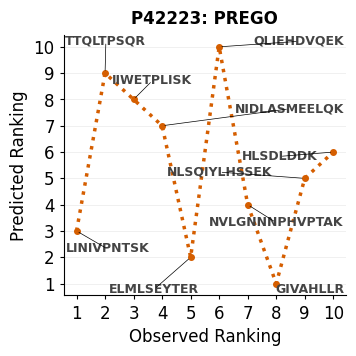

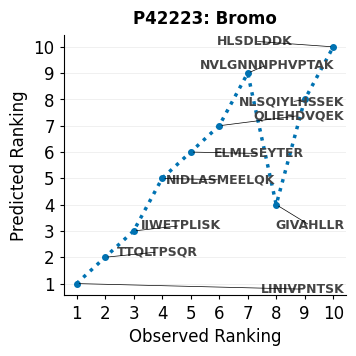

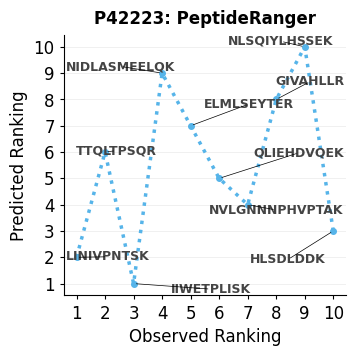

In [ ]:
plot_protein_ranking(protein_sample, x_col='true_ranking', y_col='prego ranking',color = "#D55E00", xlabel='Observed Ranking', ylabel='Predicted Ranking', title='P42223: PREGO', save_path='./fig2h_prego.pdf')
plot_protein_ranking(protein_sample, x_col='true_ranking', y_col='bromo ranking', xlabel='Observed Ranking', ylabel='Predicted Ranking', title='P42223: Bromo', save_path='./fig2g_bromo.pdf')
plot_protein_ranking(protein_sample, x_col='true_ranking', y_col='peptideranger ranking',color = "#56B4E9", xlabel='Observed Ranking', ylabel='Predicted Ranking', title='P42223: PeptideRanger', save_path='./fig2i_peptideranger.pdf')